# Feature Analysis

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
sys.path.insert(0, '..')

from src.features.build_features import ChurnFeatureEngineer

## Load Processed Features

In [3]:
train_df = pd.read_csv('../data/processed/features_v1_train.csv')
test_df = pd.read_csv('../data/processed/features_v1_test.csv')

print(f"Train shape: {train_df.shape}")
print(f"Test shape: {test_df.shape}")

# Separates features and target
X_train = train_df.drop(columns=['Churn'])
y_train = train_df['Churn']

X_test = test_df.drop(columns=['Churn'])
y_test = test_df['Churn']

Train shape: (40000, 25)
Test shape: (10000, 25)


## Feature Distribution Comparison (Before/After)

In [7]:
raw_df = pd.read_csv('../data/raw/telecom_data.csv')

print("Feature count comparison: ")
print(f"  Raw features:       {len(raw_df.columns) - 1}") # Exclude target
print(f"  Processed features: {len(X_train.columns)}")
print(f"  Increased:          {len(X_train.columns) - (len(raw_df.columns) -1)}")

Feature count comparison: 
  Raw features:       16
  Processed features: 24
  Increased:          8


## Engineered Feature Distribution

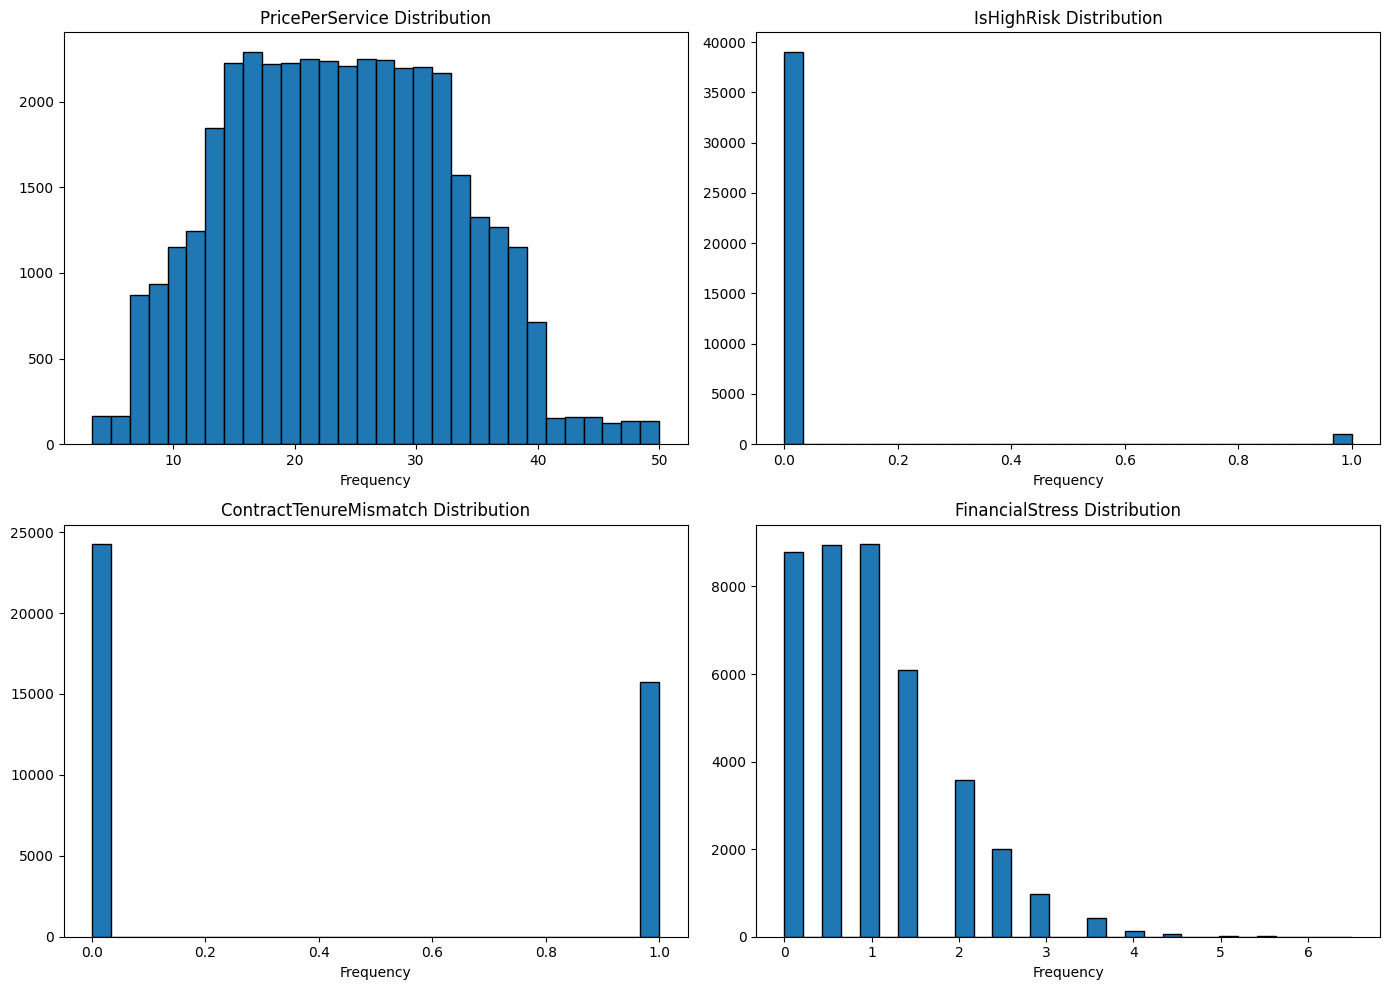

In [10]:
engineered_features = [
    'PricePerService', 'IsHighRisk', 
    'ContractTenureMismatch', 'FinancialStress'
]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, feat in enumerate(engineered_features):
    if feat in X_train.columns:
        axes[idx].hist(X_train[feat], bins=30, edgecolor='black')
        axes[idx].set_title(f"{feat} Distribution")
        axes[idx].set_xlabel(feat)
        axes[idx].set_xlabel('Frequency')

plt.tight_layout()
plt.show()

## Correlation with Target


Top 10 Features by correlation with Churn:
                   Feature  Correlation
18   ContractType_Two Year    -0.225863
6     RecentSupportTickets     0.214791
2                   Tenure    -0.207346
17   ContractType_One Year    -0.185042
5               Complaints     0.151902
3           MonthlyCharges     0.145092
16         FinancialStress     0.143008
13         PricePerService     0.137724
15  ContractTenureMismatch     0.133727
12    TenureBucket_Veteran    -0.129549


<Figure size 1200x800 with 0 Axes>

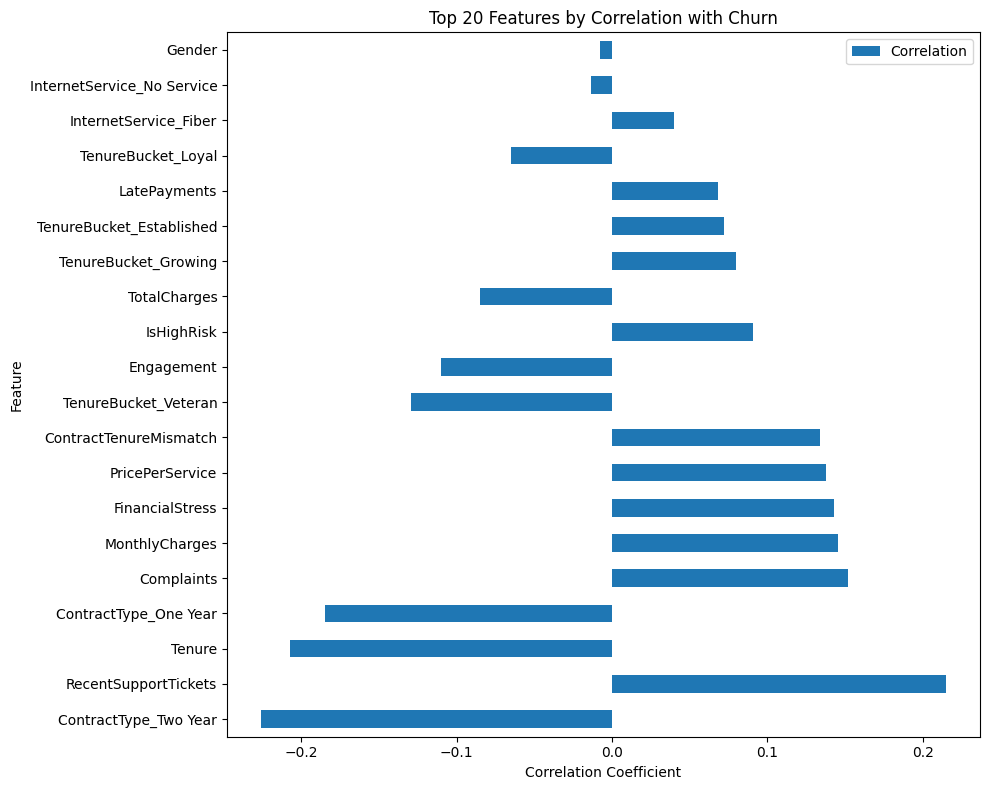

In [12]:
correlations = pd.DataFrame({
    'Feature': X_train.columns,
    'Correlation': [X_train[col].corr(y_train) for col in X_train.columns]
}).sort_values('Correlation', key=abs, ascending=False)

print("\nTop 10 Features by correlation with Churn:")
print(correlations.head(10))

plt.figure(figsize=(12, 8))
correlations.head(20).plot(x='Feature', y='Correlation', kind='barh', figsize=(10, 8))
plt.title('Top 20 Features by Correlation with Churn')
plt.xlabel('Correlation Coefficient')
plt.tight_layout()
plt.show()

## Check for Multicollinearity

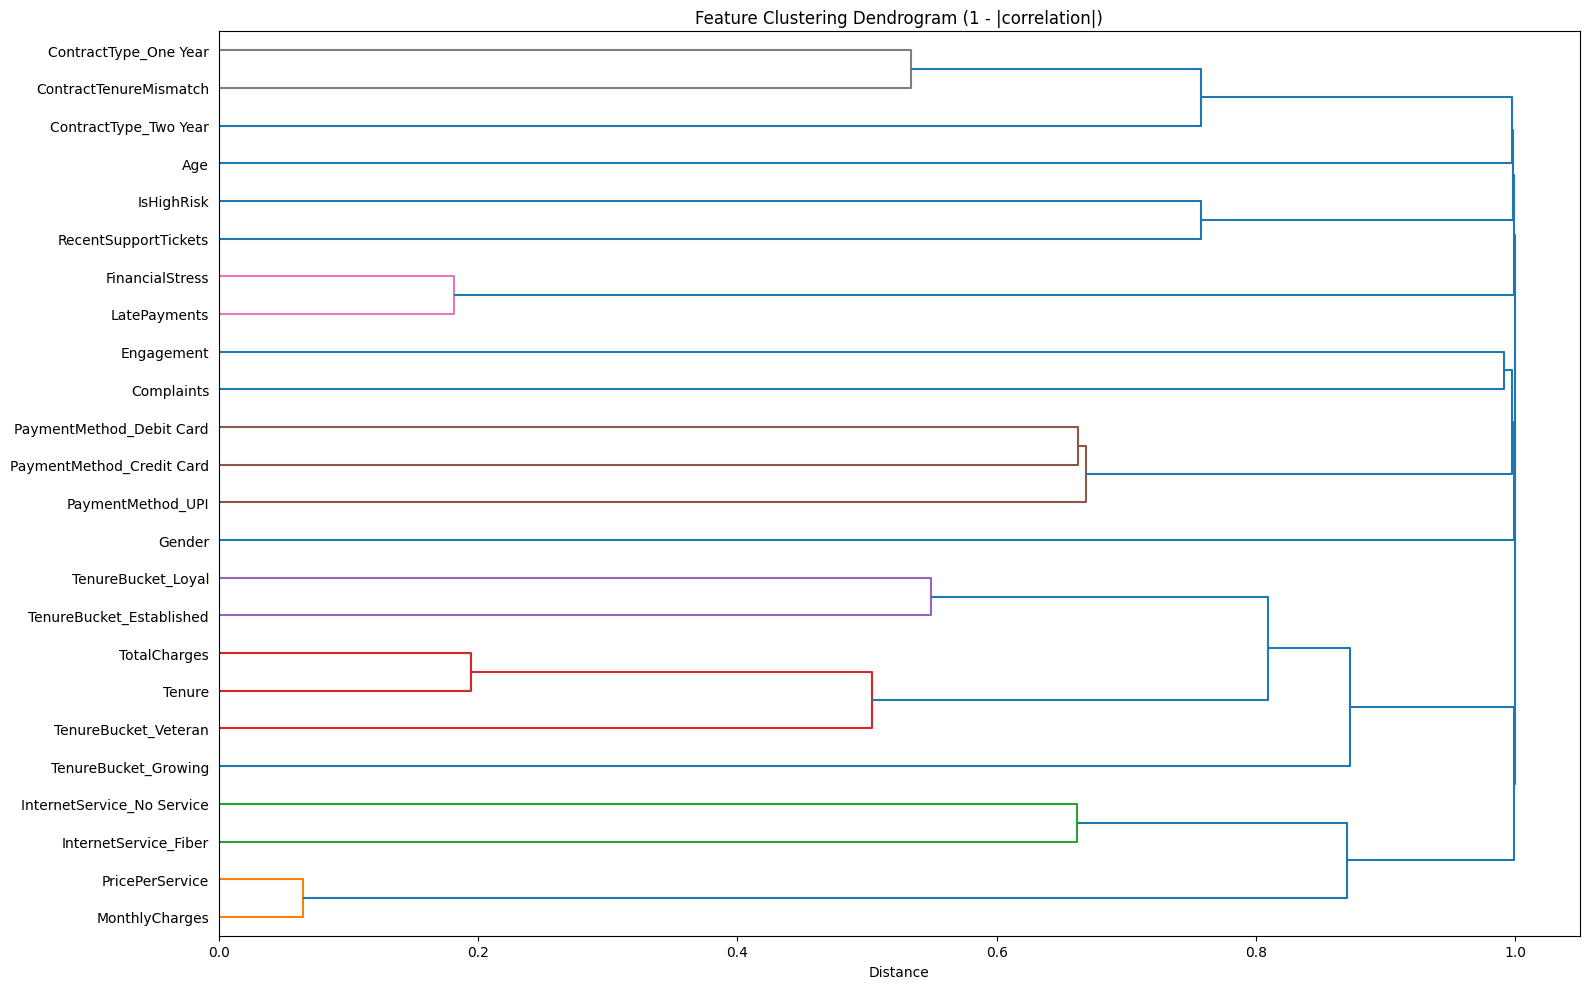

In [13]:
from scipy.cluster import hierarchy
from scipy.spatial.distance import squareform

# Claculate Correlation matrix
corr_matrix = X_train.corr()

# Convert to distance matrix
dissimalrity = 1 - abs(corr_matrix)
Z = hierarchy.linkage(squareform(dissimalrity), 'complete')

# Plot dendrogram
plt.figure(figsize=(16, 10))
dendrogram = hierarchy.dendrogram(Z, labels=X_train.columns, orientation='right')
plt.title('Feature Clustering Dendrogram (1 - |correlation|)')
plt.xlabel('Distance')
plt.tight_layout()
plt.show()

## Data Quality Verification

In [14]:
print("Data Quality Checks:")
print(f"  Missing values (train): {X_train.isnull().sum().sum()}")
print(f"  Missing values (test): {X_test.isnull().sum().sum()}")
print(f"  Infinite values (train): {np.isinf(X_train.select_dtypes(include=[np.number])).sum().sum()}")
print(f"  Infinite values (test): {np.isinf(X_test.select_dtypes(include=[np.number])).sum().sum()}")
print(f"  Duplicate values (train): {X_train.duplicated().sum()}")
print(f"  Duplicate values (test): {X_test.duplicated().sum()}")

Data Quality Checks:
  Missing values (train): 0
  Missing values (test): 0
  Infinite values (train): 0
  Infinite values (test): 0
  Duplicate values (train): 0
  Duplicate values (test): 0


## Save Feature Importance Placeholders

In [15]:
feature_importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Correlation': [X_train[col].corr(y_train) for col in X_train.columns],
    'ModelImportance_Placeholder': 0.0 # Will be filled after model training
})

feature_importance_df.to_csv('../data/processed/feature_importance_v1.csv', index=False)
print("Saved feature importance template to data/processed/feature_importance_v1.csv")

Saved feature importance template to data/processed/feature_importance_v1.csv
